# Analyse — prospects accueil jeune enfant (NAF 88.91A)

Données produites par `scripts/prospecting/fetch_securite_privee_sirene.py` avec `--activite 88.91A` (API [Recherche d'entreprises](https://api.gouv.fr/les-api/api-recherche-entreprises)).

Exemple d’export : `python scripts/prospecting/fetch_securite_privee_sirene.py --activite 88.91A --out data/prospects_creches_8891a.csv`

**Prérequis** (dans l’environnement du notebook) :

```bash
pip install pandas matplotlib
```

Optionnel pour des graphiques plus soignés : `pip install seaborn`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Chemin relatif à la racine du dépôt Regultrack
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

CSV_PATH = ROOT / "data" / "prospects_creches_8891a.csv"
assert CSV_PATH.is_file(), f"Fichier introuvable : {CSV_PATH} — lance le script d’export ou ajuste CSV_PATH."

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 60)

In [2]:
df = pd.read_csv(CSV_PATH, dtype={"siren": str, "siege_code_postal": str, "siege_departement": str})
df.head(10)

,siren,nom_complet,activite_principale,tranche_effectif_salarie,categorie_entreprise,nombre_etablissements_ouverts,siege_adresse,siege_code_postal,siege_commune,siege_departement,dirigeants
0,803884006,BABY MONTESSORI,88.91A,11,PME,15,940 Route de l'Aérodrome 84000 Avignon,84000,AVIGNON,84,personne morale
1,877985275,MARBO,88.91A,11,PME,13,11bis Avenue Emile Baudot 91300 Massy,91300,MASSY,91,FOSSOUO PACHONG (DONGMO TIANDEM)
2,889820494,LCMC,88.91A,11,PME,10,3 Rue Jean-Baptiste Dumas 75017 Paris,75017,PARIS,75,CLAUSTRE | HARANG
3,807906482,NOS PETITS POUCES - OUEST,88.91A,11,PME,9,27 Rue Georges Méliès 44100 Nantes,44100,NANTES,44,ROTURIER (LEVESQUE)
4,894002674,LNDP (LE NID DES PETITS),88.91A,11,PME,8,70 Rue Saint-françois 57535 Marange-Silvange,57535,MARANGE-SILVANGE,57,AREND
5,887721082,CHAZO,88.91A,11,PME,8,Rue Marechal Joffre 57100 Thionville,57100,THIONVILLE,57,personne morale
6,843945288,BABYNOOK,88.91A,11,PME,6,19 Rue des Epoux Lesgourgues 33400 Talence,33400,TALENCE,33,TAPPERT-PICHA (TAPPERT)
7,920093473,ARIL33,88.91A,11,PME,6,Avenue des Terrasses 64600 Anglet,64600,ANGLET,64,ARROSTEGUY
8,819440082,OUEST CRECHE,88.91A,11,PME,6,40bis Rue de Bout de Lande 35890 Laillé,35890,LAILLE,35,personne morale
9,513618546,LE PETIT HOME (LE PETIT HOME),88.91A,11,PME,6,14 Rue de la Paix 62740 Fouquières-lès-Lens,62740,FOUQUIERES-LES-LENS,62,NaN


## 1. Vue d’ensemble

In [3]:
print(f"Lignes : {len(df):,}  |  Colonnes : {df.shape[1]}")
print(f"SIREN uniques : {df['siren'].nunique():,}")
dup = df['siren'].duplicated().sum()
print(f"Doublons SIREN : {dup}")
df.dtypes

Lignes : 2,409  |  Colonnes : 11
SIREN uniques : 2,409
Doublons SIREN : 0


siren                              str
nom_complet                        str
activite_principale                str
tranche_effectif_salarie         int64
categorie_entreprise               str
nombre_etablissements_ouverts    int64
siege_adresse                      str
siege_code_postal                  str
siege_commune                      str
siege_departement                  str
dirigeants                         str
dtype: object

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (100 * missing / len(df)).round(1)
pd.DataFrame({"manquants": missing, "%": missing_pct}).query("manquants > 0")

,manquants,%
dirigeants,1194,49.6
siege_departement,1,0.0
siege_code_postal,1,0.0
siege_commune,1,0.0


## 2. Tranche d’effectif (INSEE)

Libellés indicatifs — nomenclature Sirene (niveau unité légale).

In [5]:
TRANCHE_LABELS = {
    "NN": "Non employeuse / non renseigné",
    "00": "0 salarié",
    "01": "1 ou 2",
    "02": "3 à 5",
    "03": "6 à 9",
    "11": "10 à 19",
    "12": "20 à 49",
    "22": "50 à 99",
    "31": "100 à 199",
    "32": "200 à 249",
    "41": "250 à 499",
    "42": "500 à 999",
    "51": "1 000 à 1 999",
    "52": "2 000 à 4 999",
    "53": "5 000 et plus",
}

df["tranche_libelle"] = df["tranche_effectif_salarie"].astype(str).map(TRANCHE_LABELS).fillna("(autre)")
vc_t = df["tranche_effectif_salarie"].value_counts().sort_index()
tbl = vc_t.rename("nombre").reset_index()
tbl.columns = ["tranche_code", "nombre"]
tbl["libelle"] = tbl["tranche_code"].astype(str).map(TRANCHE_LABELS).fillna("(autre)")
tbl

,tranche_code,nombre,libelle
0,11,1561,10 à 19
1,12,743,20 à 49
2,22,61,50 à 99
3,31,16,100 à 199
4,32,15,200 à 249
5,41,7,250 à 499
6,42,2,500 à 999
7,51,3,1 000 à 1 999
8,53,1,5 000 et plus


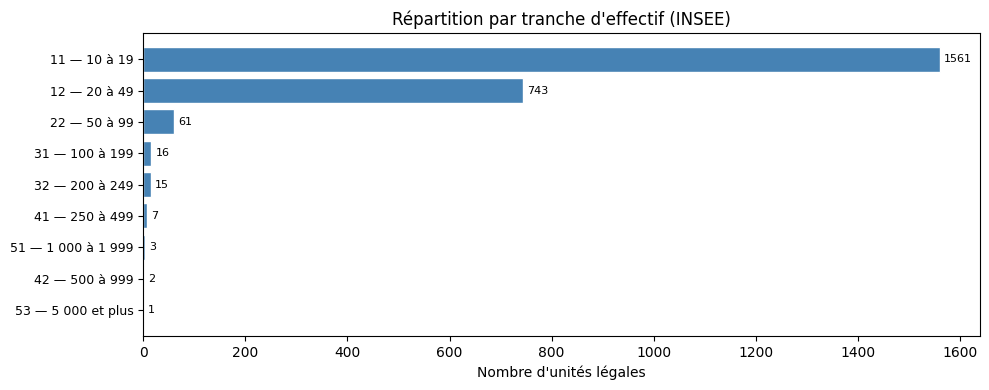

In [6]:
plot_tbl = tbl.sort_values("nombre", ascending=True)
codes = plot_tbl["tranche_code"].astype(str)
y_labels = [f"{c} — {TRANCHE_LABELS.get(c, c)}" for c in codes]
fig_h = max(4.0, 0.38 * len(plot_tbl))
fig, ax = plt.subplots(figsize=(10, fig_h))
bars = ax.barh(range(len(plot_tbl)), plot_tbl["nombre"].values, color="steelblue", edgecolor="white")
ax.set_yticks(range(len(plot_tbl)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel("Nombre d'unités légales")
ax.set_title("Répartition par tranche d'effectif (INSEE)")
ax.bar_label(bars, labels=[f"{int(v)}" for v in plot_tbl["nombre"].values], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

## 3. Catégorie d’entreprise (PME / ETI / GE)

,nombre
categorie_entreprise,
PME,2128
ETI,240
GE,41


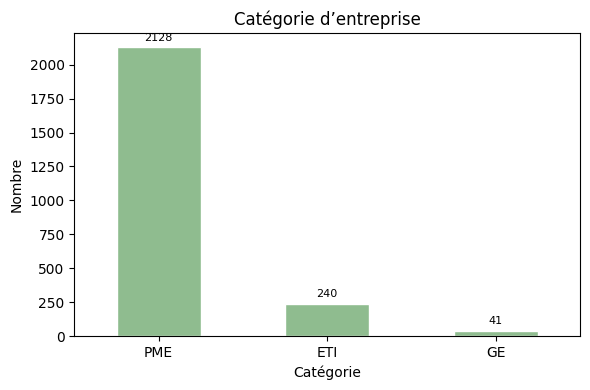

In [7]:
vc_cat = df["categorie_entreprise"].fillna("(non renseigné)").value_counts()
display(vc_cat.to_frame("nombre"))

fig, ax = plt.subplots(figsize=(6, 4))
vc_cat.plot(kind="bar", ax=ax, color="darkseagreen", edgecolor="white")
ax.set_ylabel("Nombre")
ax.set_xlabel("Catégorie")
ax.set_title("Catégorie d’entreprise")
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Département du siège (top 20)

,nombre
siege_departement,
92,191
69,120
974,101
75,94
59,93
13,80
33,79
31,75
44,69


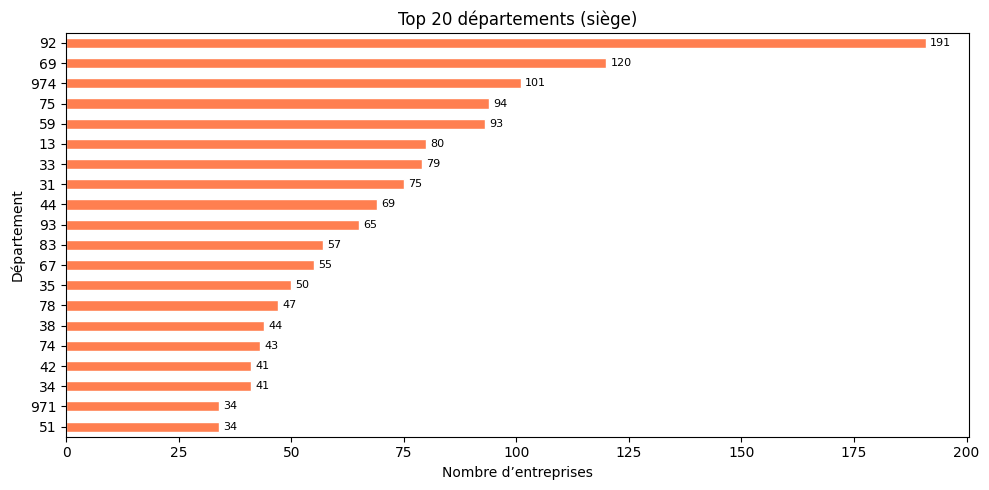

In [8]:
dept = df["siege_departement"].fillna("(manquant)").astype(str).str.zfill(2)
vc_dept = dept.value_counts().head(20)
display(vc_dept.to_frame("nombre"))

fig, ax = plt.subplots(figsize=(10, 5))
vc_dept.plot(kind="barh", ax=ax, color="coral", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Nombre d’entreprises")
ax.set_ylabel("Département")
ax.set_title("Top 20 départements (siège)")
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

## 5. Nombre d’établissements ouverts

count    2409.00
mean        3.16
std        15.42
min         0.00
25%         1.00
50%         1.00
75%         2.00
max       496.00


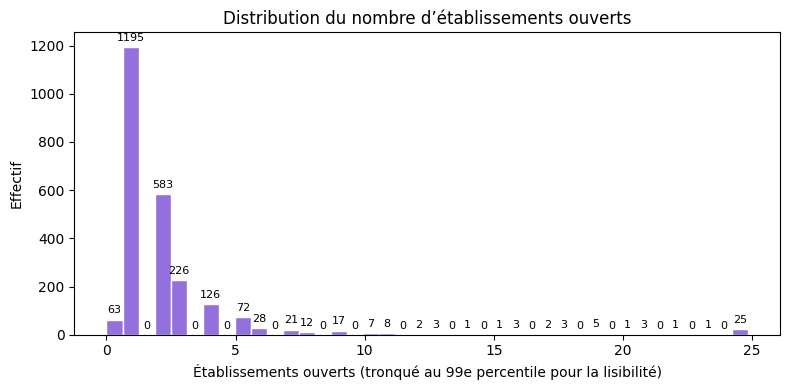

In [9]:
neo = pd.to_numeric(df["nombre_etablissements_ouverts"], errors="coerce")
print(neo.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bins = min(40, max(10, neo.dropna().nunique()))
counts, bin_edges, patches = ax.hist(neo.dropna().clip(upper=neo.quantile(0.99)), bins=bins, color="mediumpurple", edgecolor="white")
for count, patch in zip(counts, patches):
    ax.annotate(
        f"{int(count)}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_xlabel("Établissements ouverts (tronqué au 99e percentile pour la lisibilité)")
ax.set_ylabel("Effectif")
ax.set_title("Distribution du nombre d’établissements ouverts")
plt.tight_layout()
plt.show()

## 6. Dirigeants renseignés dans l’API

In [10]:
dir_col = df["dirigeants"].fillna("").astype(str).str.strip()
has_dir = (dir_col != "") & (~dir_col.str.lower().isin(["nan", "none"]))
print(f"Lignes avec dirigeant(s) texte non vide : {has_dir.sum():,} ({100 * has_dir.mean():.1f} %)")

nb_parts = dir_col.str.count(r"\|") + 1
nb_parts = nb_parts.where(has_dir, 0)
print("Nombre de blocs séparés par « | » (plusieurs entrées possibles) :")
display(nb_parts.value_counts().sort_index().head(15).to_frame("lignes"))

Lignes avec dirigeant(s) texte non vide : 1,215 (50.4 %)
Nombre de blocs séparés par « | » (plusieurs entrées possibles) :


,lignes
dirigeants,
0,1194
1,942
2,220
3,28
4,13
5,4
7,1
8,1
9,1


## 7. Échantillon pour prospection (ex. PME, 10–49 salariés, 2+ sites)

À adapter selon ton ICP ; filtre d’exemple ci-dessous.

In [11]:
mask_icp = (
    df["categorie_entreprise"].eq("PME")
    & df["tranche_effectif_salarie"].astype(str).isin(["11", "12"])
    & (pd.to_numeric(df["nombre_etablissements_ouverts"], errors="coerce") >= 2)
)
shortlist = df.loc[mask_icp, ["siren", "nom_complet", "tranche_libelle", "nombre_etablissements_ouverts", "siege_commune", "siege_departement", "dirigeants"]].copy()
print(f"Shortlist (exemple ICP) : {len(shortlist):,} lignes")
shortlist.head(15)

Shortlist (exemple ICP) : 869 lignes


,siren,nom_complet,tranche_libelle,nombre_etablissements_ouverts,siege_commune,siege_departement,dirigeants
0,803884006,BABY MONTESSORI,10 à 19,15,AVIGNON,84,personne morale
1,877985275,MARBO,10 à 19,13,MASSY,91,FOSSOUO PACHONG (DONGMO TIANDEM)
2,889820494,LCMC,10 à 19,10,PARIS,75,CLAUSTRE | HARANG
3,807906482,NOS PETITS POUCES - OUEST,10 à 19,9,NANTES,44,ROTURIER (LEVESQUE)
4,894002674,LNDP (LE NID DES PETITS),10 à 19,8,MARANGE-SILVANGE,57,AREND
5,887721082,CHAZO,10 à 19,8,THIONVILLE,57,personne morale
6,843945288,BABYNOOK,10 à 19,6,TALENCE,33,TAPPERT-PICHA (TAPPERT)
7,920093473,ARIL33,10 à 19,6,ANGLET,64,ARROSTEGUY
8,819440082,OUEST CRECHE,10 à 19,6,LAILLE,35,personne morale
9,513618546,LE PETIT HOME (LE PETIT HOME),10 à 19,6,FOUQUIERES-LES-LENS,62,NaN


In [12]:
# Export optionnel pour travail dans un tableur
OUT = ROOT / "data" / "prospects_shortlist_icp_exemple.csv"
# shortlist.to_csv(OUT, index=False)
# print("Écrit :", OUT)